In [31]:
import torch
import numpy as np
import pandas as pd
from chronos import BaseChronosPipeline, Chronos2Pipeline

In [32]:
map_forecast_path = "data/map-forecast"
df_test = pd.read_csv(f"{map_forecast_path}/dataframe/df_map_test.csv")
# get list of unique stay_id
test_ids = list(set(df_test['stay_id'].values))
print(test_ids)
df_test

[np.int64(34617352), np.int64(39804682), np.int64(37057036), np.int64(37323533), np.int64(31959184), np.int64(35024147), np.int64(30913302), np.int64(36091287), np.int64(30585761), np.int64(31338022), np.int64(34592300), np.int64(35436337), np.int64(32391858), np.int64(35544374), np.int64(32283063), np.int64(35727289), np.int64(38197705), np.int64(32155744), np.int64(34531557), np.int64(32453351), np.int64(31316840), np.int64(36107367), np.int64(34170353), np.int64(31205490), np.int64(30849778), np.int64(35044342)]


,stay_id,charttime,MAP,age,gender_female,Heart Rate,Respiratory Rate,Temperature Fahrenheit,PEEP set,GCS - Motor Response,NaCl 0.9%,Norepinephrine
0,34592300,2157-12-19 15:00:00,114.0,55.0,1.0,96.0,11.0,98.6,0.0,6.0,0.000000,0.0
1,34592300,2157-12-19 16:00:00,112.0,55.0,1.0,73.0,17.0,97.6,0.0,6.0,0.000000,0.0
2,34592300,2157-12-19 17:00:00,103.0,55.0,1.0,76.5,14.0,97.6,0.0,6.0,128.333333,0.0
3,34592300,2157-12-19 18:00:00,96.0,55.0,1.0,81.0,14.0,97.6,0.0,6.0,49.999999,0.0
4,34592300,2157-12-19 19:00:00,87.0,55.0,1.0,83.0,16.0,97.6,0.0,6.0,149.999996,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
2752,36107367,2148-01-30 12:00:00,86.0,69.0,1.0,85.0,23.0,97.5,0.0,6.0,110.000000,0.0
2753,36107367,2148-01-30 13:00:00,85.0,69.0,1.0,81.0,15.0,97.5,0.0,6.0,10.000000,0.0
2754,36107367,2148-01-30 14:00:00,96.0,69.0,1.0,71.0,15.0,97.5,0.0,6.0,10.000000,0.0
2755,36107367,2148-01-30 15:00:00,80.0,69.0,1.0,83.0,14.0,97.4,0.0,6.0,10.000000,0.0


In [33]:
df_test.columns

Index(['stay_id', 'charttime', 'MAP', 'age', 'gender_female', 'Heart Rate',
       'Respiratory Rate', 'Temperature Fahrenheit', 'PEEP set',
       'GCS - Motor Response', 'NaCl 0.9%', 'Norepinephrine'],
      dtype='object')

In [34]:
# Initialise Chronos Pipeline (this takes some time as the model contains 120 M parameter)
pipeline: Chronos2Pipeline = BaseChronosPipeline.from_pretrained(
    "amazon/chronos-2", 
    device_map="cpu", 
    dtype=torch.float32
)

In [43]:
chronos_windows_results = []
window_size = 18  # 12 context + 6 forecast

for sid in test_ids:
    patient_stay = df_test[df_test['stay_id'] == sid].sort_values('charttime')
    
    # Slide the window across the patient's entire stay
    # If a patient has 20 points, this will create 3 windows: 
    # (0-18), (1-19), (2-20)
    for start_idx in range(0, len(patient_stay) - window_size + 1):
        full_window = patient_stay.iloc[start_idx : start_idx + window_size]
        
        context_data = full_window.iloc[:12] # First 12
        actual_data = full_window.iloc[12:]  # Last 6
        
        # Prepare context for Chronos-2
        context_tensor = torch.tensor(context_data["MAP"].values, dtype=torch.float32).view(1, 1, -1)

        with torch.no_grad():
            forecast = pipeline.predict(context_tensor, prediction_length=6)
        
        # Chronos-2 median prediction (quantile 0.5 is at index 4)
        pred_median = forecast[0][0, 4, :].numpy()
        
        # Store window results
        chronos_windows_results.append({
            'stay_id': sid,
            'window_start_idx': start_idx,
            't_plus_1_actual': actual_data['MAP'].iloc[0],
            't_plus_1_pred': pred_median[0],
            't_plus_3_actual': actual_data['MAP'].iloc[2],
            't_plus_3_pred': pred_median[2],
            't_plus_6_actual': actual_data['MAP'].iloc[5],
            't_plus_6_pred': pred_median[5],
            't_actual_full': actual_data['MAP'],
            't_pred_full': pred_median
        })

# Create the final comparison DataFrame
chronos_final_eval_df = pd.DataFrame(chronos_windows_results)

# Calculate Global MAE (in mmHg)
mae_1 = np.mean(np.abs(chronos_final_eval_df['t_plus_1_actual'] - chronos_final_eval_df['t_plus_1_pred']))
mae_3 = np.mean(np.abs(chronos_final_eval_df['t_plus_3_actual'] - chronos_final_eval_df['t_plus_3_pred']))
mae_6 = np.mean(np.abs(chronos_final_eval_df['t_plus_6_actual'] - chronos_final_eval_df['t_plus_6_pred']))

print(f"Chronos-2 Global Results (N={len(chronos_final_eval_df)} windows):")
print(f"t+1: {mae_1:.2f} | t+3: {mae_3:.2f} | t+6: {mae_6:.2f}")

Chronos-2 Global Results (N=2315 windows):
t+1: 9.93 | t+3: 11.71 | t+6: 13.37


In [52]:
chronos_final_eval_df.head()

,stay_id,window_start_idx,t_plus_1_actual,t_plus_1_pred,t_plus_3_actual,t_plus_3_pred,t_plus_6_actual,t_plus_6_pred,t_actual_full,t_pred_full
0,34617352,0,63.0,57.195351,59.0,45.416862,214.0,35.287533,650 63.0 651 64.0 652 59.0 653 ...,"[57.19535, 52.03703, 45.416862, 39.861855, 35...."
1,34617352,1,64.0,58.472649,61.0,45.431931,63.0,38.608952,651 64.0 652 59.0 653 61.0 654 ...,"[58.47265, 52.14994, 45.43193, 40.647846, 38.3..."
2,34617352,2,59.0,64.099998,56.0,54.417549,64.0,41.330910,652 59.0 653 61.0 654 56.0 655 ...,"[64.1, 60.172802, 54.41755, 47.659805, 43.1700..."
3,34617352,3,61.0,57.782410,214.0,52.440109,65.0,46.793808,653 61.0 654 56.0 655 214.0 656 ...,"[57.78241, 54.798195, 52.44011, 49.42016, 48.2..."
4,34617352,4,56.0,58.811394,63.0,56.530781,63.0,55.467834,654 56.0 655 214.0 656 63.0 657 ...,"[58.811394, 57.824554, 56.53078, 55.930763, 55..."


In [44]:
multivariate_results_list = []
window_size = 18

# Ensure we use the sanitized names if you renamed them for the TFT
dynamic_features = [
    'MAP', 'Heart Rate', 'Respiratory Rate', 'Temperature Fahrenheit', 
    'PEEP set', 'GCS - Motor Response', 'NaCl 0.9%', 'Norepinephrine'
]

for sid in test_ids:
    patient_stay = df_test[df_test['stay_id'] == sid].sort_values('charttime')
    
    # Sliders: Evaluate on every possible window for a fair comparison
    for start_idx in range(0, len(patient_stay) - window_size + 1):
        full_window = patient_stay.iloc[start_idx : start_idx + window_size]
        
        context_data = full_window.iloc[:12] 
        actual_data = full_window.iloc[12:]     
        
        # Prepare 3D Context Tensor: (1, n_variates, 12)
        context_values = context_data[dynamic_features].values.T
        context_tensor = torch.tensor(context_values, dtype=torch.float32).unsqueeze(0)
        
        with torch.no_grad():
            forecast_list = pipeline.predict(context_tensor, prediction_length=6)
        
        # Chronos-2 defaults: index 4 is usually the 0.5 (median) quantile
        forecast_tensor = forecast_list[0]
        pred_median = forecast_tensor[0, 4, :].numpy() 
        
        multivariate_results_list.append({
            'stay_id': sid,
            'window_start': start_idx,
            't_plus_1_actual': actual_data['MAP'].iloc[0],
            't_plus_1_pred': pred_median[0],
            't_plus_3_actual': actual_data['MAP'].iloc[2],
            't_plus_3_pred': pred_median[2],
            't_plus_6_actual': actual_data['MAP'].iloc[5],
            't_plus_6_pred': pred_median[5],
            't_actual_full': actual_data['MAP'],
            't_pred_full': pred_median
        })

chronos_multi_eval_df = pd.DataFrame(multivariate_results_list)

# Calculate Global Metrics for your report
mae_1 = np.mean(np.abs(chronos_multi_eval_df['t_plus_1_actual'] - chronos_multi_eval_df['t_plus_1_pred']))
mae_3 = np.mean(np.abs(chronos_multi_eval_df['t_plus_3_actual'] - chronos_multi_eval_df['t_plus_3_pred']))
mae_6 = np.mean(np.abs(chronos_multi_eval_df['t_plus_6_actual'] - chronos_multi_eval_df['t_plus_6_pred']))

print(f"Chronos-2 Multi Results (Windows: {len(chronos_multi_eval_df)}):")
print(f"t+1: {mae_1:.2f} | t+3: {mae_3:.2f} | t+6: {mae_6:.2f}")

Chronos-2 Multi Results (Windows: 2315):
t+1: 9.75 | t+3: 11.51 | t+6: 13.15


### Visualisation

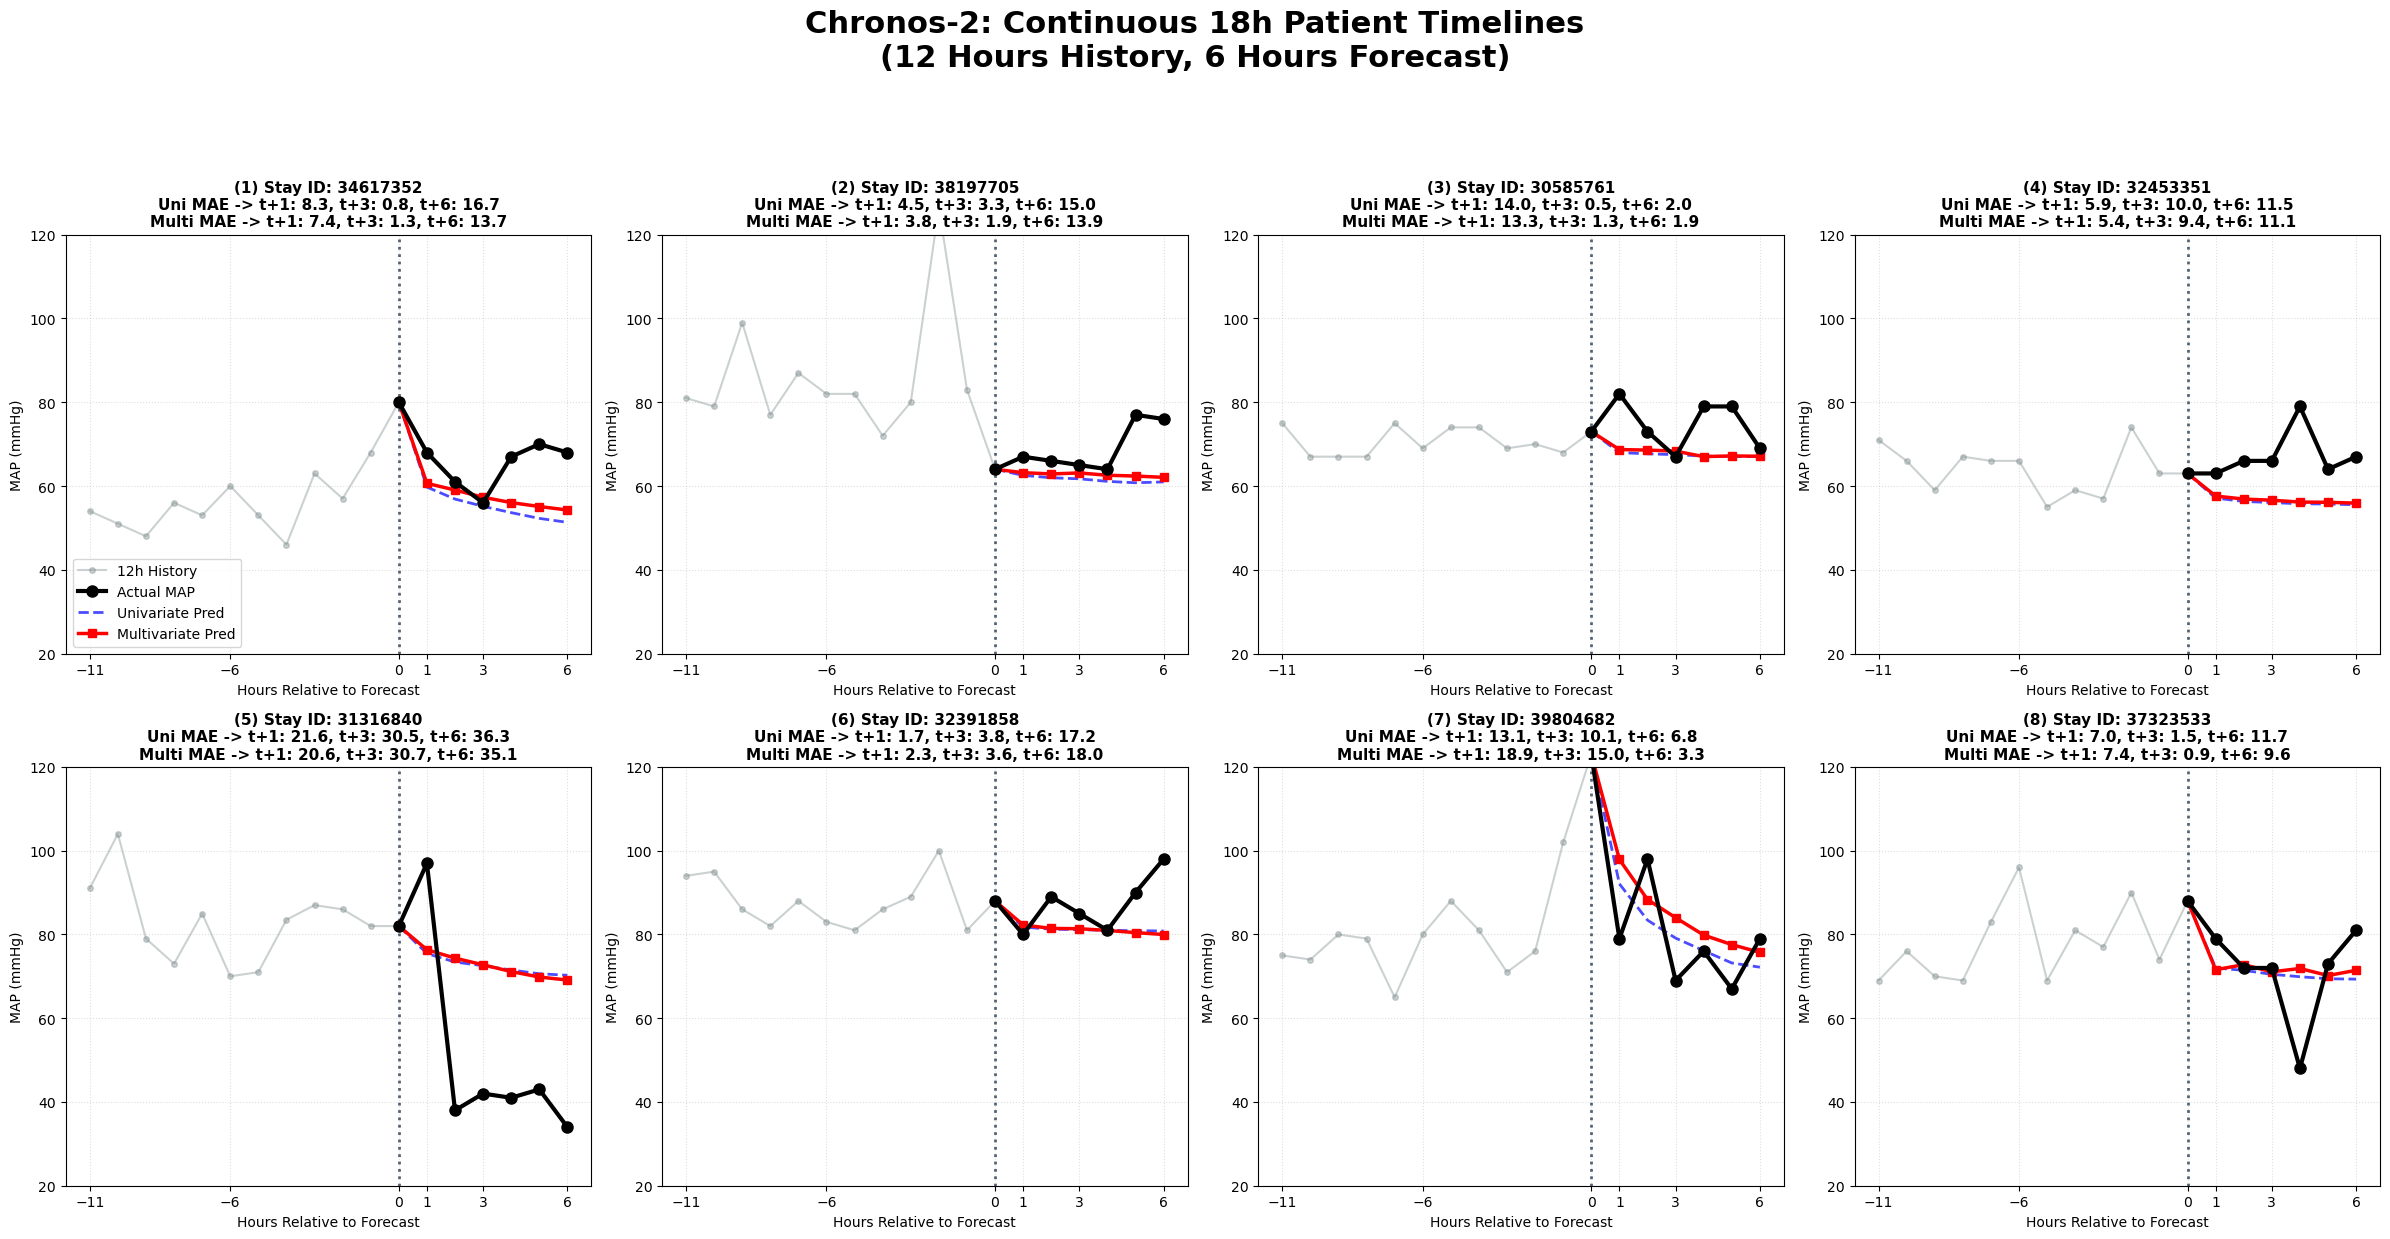

In [58]:
# --- 1. SETTINGS ---
target_stay_ids = [34617352, 38197705, 30585761, 32453351, 31316840, 32391858, 39804682, 37323533]

# --- 2. THE VISUALIZATION WITH CONNECTED LINES ---
fig, axes = plt.subplots(2, 4, figsize=(24, 13))
fig.suptitle("Chronos-2: Continuous 18h Patient Timelines\n(12 Hours History, 6 Hours Forecast)", 
             fontsize=22, fontweight='bold', y=0.98)

for i, sid in enumerate(target_stay_ids):
    ax = axes[i // 4, i % 4]
    
    # 1. Fetch History and Results
    patient_full_history = df_test[df_test['stay_id'] == sid].sort_values('charttime')
    history_vals = patient_full_history.iloc[-18:-6]['MAP'].values # 12 values
    history_hours = np.arange(-11, 1) # -11 to 0
    
    # Get the specific results for this ID
    row_uni = results_uni_df[results_uni_df['stay_id'] == sid].iloc[-1]
    row_multi = results_multi_df[results_multi_df['stay_id'] == sid].iloc[-1]
    
    actual_vals = np.array(row_uni['t_actual_full'])
    pred_uni_vals = np.array(row_uni['t_pred_full'])
    pred_multi_vals = np.array(row_multi['t_pred_full'])
    forecast_hours = np.arange(1, 7)

    # 2. STITCHING LOGIC (Connecting Hour 0 to Hour 1)
    last_hist_val = history_vals[-1]
    
    # Create continuous X-axis for the forecast part (0 to 6)
    full_forecast_hours = np.insert(forecast_hours, 0, 0)
    
    # Stitch values
    stitch_actual = np.insert(actual_vals, 0, last_hist_val)
    stitch_uni = np.insert(pred_uni_vals, 0, last_hist_val)
    stitch_multi = np.insert(pred_multi_vals, 0, last_hist_val)

    # --- PLOTTING ---
    # A. History (The fixed past - Gray)
    ax.plot(history_hours, history_vals, color='#7f8c8d', linestyle='-', marker='o', 
            markersize=4, alpha=0.4, label="12h History")
    
    # B. Connected Actuals (Black)
    ax.plot(full_forecast_hours, stitch_actual, 'k-o', label="Actual MAP", linewidth=3, markersize=8, zorder=3)
    
    # C. Connected Predictions (Uni = Blue Dashed, Multi = Red Solid)
    ax.plot(full_forecast_hours, stitch_uni, 'b--', label="Univariate Pred", alpha=0.7, linewidth=2)
    ax.plot(full_forecast_hours, stitch_multi, 'r-s', label="Multivariate Pred", linewidth=2.5)
    
    # Visual cues
    ax.axvline(0, color='#2c3e50', linestyle=':', linewidth=2, alpha=0.8)
    
    # 3. METRICS CALCULATION (Both Uni and Multi)
    m_uni = get_point_maes(actual_vals, pred_uni_vals)
    m_multi = get_point_maes(actual_vals, pred_multi_vals)
    
    # Title with numbering and separate metric lines
    title_str = (f"({i+1}) Stay ID: {sid}\n"
                 f"Uni MAE -> t+1: {m_uni['mae_1']:.1f}, t+3: {m_uni['mae_3']:.1f}, t+6: {m_uni['mae_6']:.1f}\n"
                 f"Multi MAE -> t+1: {m_multi['mae_1']:.1f}, t+3: {m_multi['mae_3']:.1f}, t+6: {m_multi['mae_6']:.1f}")
    
    ax.set_title(title_str, fontsize=11, fontweight='semibold')
    
    # Formatting
    ax.set_ylim(20, 120)
    ax.set_xticks([-11, -6, 0, 1, 3, 6])
    ax.set_xlabel("Hours Relative to Forecast", fontsize=10)
    ax.set_ylabel("MAP (mmHg)", fontsize=10)
    ax.grid(True, linestyle=':', alpha=0.4)
    
    if i == 0:
        ax.legend(loc='lower left', fontsize=10, frameon=True)

plt.tight_layout(rect=[0, 0.03, 1, 0.92])
plt.show()

In [57]:
chronos_visual_df = results_multi_df[results_multi_df['stay_id'].isin(target_stay_ids)].copy()
chronos_visual_df = chronos_visual_df.groupby('stay_id').tail(1)
chronos_visual_df = chronos_visual_df[['stay_id', 't_pred_full']].rename(columns={'t_pred_full': 'preds'})
chronos_visual_df

,stay_id,preds
23,34617352,"[60.639355, 59.033833, 57.317013, 56.041225, 5..."
24,39804682,"[97.90019, 88.32652, 84.00538, 79.852684, 77.5..."
126,37323533,"[71.58363, 72.78591, 71.07364, 71.87182, 70.19..."
326,30585761,"[68.700714, 68.58111, 68.327995, 67.01951, 67...."
751,32391858,"[82.26613, 81.44538, 81.36836, 80.96019, 80.43..."
1239,38197705,"[63.17939, 62.882706, 63.115158, 62.568455, 62..."
1623,32453351,"[57.599876, 56.88669, 56.605362, 56.164894, 56..."
1987,31316840,"[76.35154, 74.349525, 72.748886, 71.1394, 69.8..."


In [59]:
chronos_visual_df.to_csv('chronos_visual.csv', index=False)